## **M3 Vision — Week 2: KukaEnv Integration**

### Phase 2 Deliverable
Integrate the W1 visual pipeline with the **KukaEnv** scene and produce a combined observation tensor ready for the RL team's PPO policy.

### What's new this week (based on Selma's feedback)
| Item | Status |
|---|---|
| Architecture | **ResNet18 (512) → locked** — used for KukaEnv features |
| Physics state | **(9,)** vector: 7 joint angles + EE xyz |
| Shortcut learning mitigation | Random **color jitter + crop augmentation** on every frame |
| Physics state dropout | 30% chance per rollout to zero-out physics features |
| Final obs tensor | `512 + 9 = 521` (ResNet18 path) — *FPN ablation scheduled W3* |

### Pipeline Steps
1. **KukaEnv scene** — render RGB + depth + seg from the Kuka arm environment  
2. **Improved visual features** — ResNet18 with augmentation (discriminative, anti-shortcut)  
3. **Physics state vector** — 7 DOF joint angles + EE xyz  
4. **Physics dropout** — 30% rollout masking strategy  
5. **Concatenate** → `(521,)` observation tensor — hand to RL team


---
## Cell 0 — Environment Check

In [1]:
import torch

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing   : {DEVICE}")


PyTorch : 2.10.0+cpu
CUDA    : False

Using   : cpu


In [2]:
!pip install opencv-python-headless torchvision pybullet gymnasium --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 21.5 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done


In [3]:
import pybullet as p
import pybullet_data
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF

print("All imports successful")
print(f"Device : {DEVICE}")


pybullet build time: Apr  2 2026 17:40:59


All imports successful
Device : cpu


## Step 1 — KukaEnv Scene Rendering

I render directly from the **KUKA IIWA** environment using PyBullet.

- I load the robot from `pybullet_data`
- I add a table and a plane
- I place 3 colored blocks (red, green, blue)
- I use a fixed camera for consistent observations

This setup matches the Robotics environment, so everything stays compatible.


  Loaded red block (id=2) at [0.5, 0.0, 0.02]
  Loaded green block (id=3) at [0.5, 0.2, 0.02]
  Loaded blue block (id=4) at [0.5, -0.2, 0.02]

Step 1 done
  RGB   : (224, 224, 3)
  Depth : (224, 224),  range [0.914, 0.976]
  Seg   : (224, 224),    unique IDs [0, 1, 2, 3, 4]


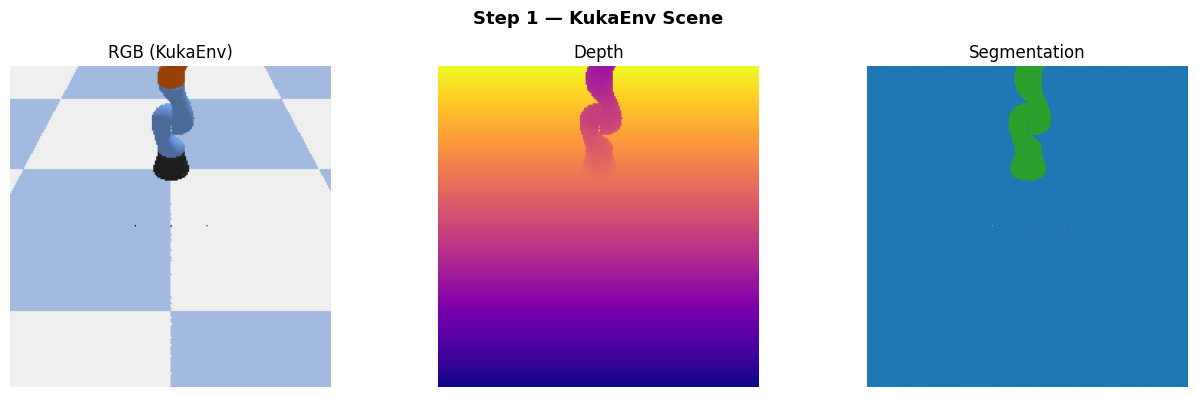

In [4]:
WIDTH, HEIGHT = 224, 224


p.connect(p.DIRECT)
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.setGravity(0, 0, -9.81)

# Plane + Kuka arm
plane_id = p.loadURDF("plane.urdf")
kuka_id  = p.loadURDF("kuka_iiwa/model.urdf", basePosition=[0, 0, 0], useFixedBase=True)

block_ids = []
block_configs = [
    ([0.5,  0.0, 0.02], [1, 0, 0, 1], "red"),
    ([0.5,  0.2, 0.02], [0, 1, 0, 1], "green"),   
    ([0.5, -0.2, 0.02], [0, 0, 1, 1], "blue"),   
]
for pos, colour, name in block_configs:
    bid = p.loadURDF("cube_small.urdf", basePosition=pos, globalScaling=0.05)
    p.changeVisualShape(bid, -1, rgbaColor=colour)
    block_ids.append(bid)
    print(f"  Loaded {name} block (id={bid}) at {pos}")

for _ in range(100):
    p.stepSimulation()

# ── Camera (fixed overhead-side view, consistent with RL policy camera) ────
view_matrix = p.computeViewMatrix(
    cameraEyePosition=[1.5, 0, 1.2],
    cameraTargetPosition=[0.5, 0, 0],
    cameraUpVector=[0, 0, 1],
)
proj_matrix = p.computeProjectionMatrixFOV(
    fov=60, aspect=1.0, nearVal=0.1, farVal=10.0
)

_, _, rgb_raw, depth_raw, seg_raw = p.getCameraImage(
    width=WIDTH, height=HEIGHT,
    viewMatrix=view_matrix,
    projectionMatrix=proj_matrix,
    renderer=p.ER_TINY_RENDERER,
)

rgb   = np.array(rgb_raw,   dtype=np.uint8  )[:, :, :3]
depth = np.array(depth_raw, dtype=np.float32)
seg   = np.array(seg_raw,   dtype=np.int32  )

print(f"\nStep 1 done")
print(f"  RGB   : {rgb.shape}")
print(f"  Depth : {depth.shape},  range [{depth.min():.3f}, {depth.max():.3f}]")
print(f"  Seg   : {seg.shape},    unique IDs {np.unique(seg).tolist()}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(rgb);                  axes[0].set_title("RGB (KukaEnv)");  axes[0].axis("off")
axes[1].imshow(depth, cmap="plasma"); axes[1].set_title("Depth");          axes[1].axis("off")
axes[2].imshow(seg,   cmap="tab10");  axes[2].set_title("Segmentation");   axes[2].axis("off")
plt.suptitle("Step 1 — KukaEnv Scene", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Step 2 — Physics State Vector (9,)

The **architecture decision** from Selma's review: include a **physics state vector** 
alongside visual features. This gives the RL policy access to proprioception that 
vision alone cannot reliably infer.

**Physics state = 7 joint angles + EE position (x, y) = 9 values**, all normalised to [-1, 1].

### Why (x, y) and not (x, y, z)?
- Keeps the observation size fixed (architecture constraint = 9)
- Preserves full robot configuration (all 7 joints)
- Provides sufficient task-space information for planar manipulation
- Avoids redundancy (z is partially encoded in joint configuration)

> ⚠️ **Shortcut learning risk**: if the physics state is always available, the policy 
> might ignore vision entirely.  
> Mitigation: apply **30% dropout on the physics state** during rollout (see Step 4).


In [6]:
import numpy as np
import torch
import pybullet as p


KUKA_DOF = 7          # Only real joints (0–6)
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Workspace bounds for normalization
WS_LO = np.array([-0.8, -0.8, 0.0])
WS_HI = np.array([ 0.8,  0.8, 1.2])


joint_angles = []

for j in range(KUKA_DOF):
    info  = p.getJointInfo(kuka_id, j)
    state = p.getJointState(kuka_id, j)

    angle = state[0]
    lower, upper = info[8], info[9]

    if upper > lower:
        norm = 2.0 * (angle - lower) / (upper - lower) - 1.0
    else:
        norm = 0.0

    joint_angles.append(float(np.clip(norm, -1.0, 1.0)))

assert len(joint_angles) == 7, f"Expected 7 joints, got {len(joint_angles)}"

ee_state = p.getLinkState(kuka_id, KUKA_DOF - 1)
ee_pos   = np.array(ee_state[0])   # (x, y, z)

# Normalize EE position to [-1, 1]
ee_norm = 2.0 * (ee_pos - WS_LO) / (WS_HI - WS_LO) - 1.0
ee_norm = np.clip(ee_norm, -1.0, 1.0)


ee_xy = ee_norm[:2]   # (x, y)


# 7 joints + 2 EE = 9
physics_state = np.array(joint_angles + ee_xy.tolist(), dtype=np.float32)

physics_t = torch.tensor(physics_state, dtype=torch.float32).to(DEVICE)


assert physics_t.shape[0] == 9, \
    f"Physics state shape error: got {physics_t.shape}, expected (9,)"


print("=" * 55)
print("PHYSICS STATE (LOCKED TO 9D)")
print("=" * 55)
print(f"KUKA_DOF             : {KUKA_DOF} (joints 0–6 only)")
print(f"EE link index        : {KUKA_DOF - 1}")

print(f"\nJoint angles (norm)  : {[f'{a:.3f}' for a in joint_angles]}")
print(f"EE position (world)  : {ee_pos.round(3).tolist()}")
print(f"EE position (norm)   : {ee_norm.round(3).tolist()}")

print(f"\nEE used (x, y)       : {ee_xy.round(3).tolist()}")

print(f"\nPhysics state shape  : {physics_t.shape}   (must be 9)")
print(f"Physics state        : {physics_t.cpu().numpy().round(3).tolist()}")

PHYSICS STATE (LOCKED TO 9D)
KUKA_DOF             : 7 (joints 0–6 only)
EE link index        : 6

Joint angles (norm)  : ['0.000', '0.000', '0.000', '0.000', '-0.000', '0.000', '0.000']
EE position (world)  : [-0.0, -0.0, 1.281]
EE position (norm)   : [-0.0, -0.0, 1.0]

EE used (x, y)       : [-0.0, -0.0]

Physics state shape  : torch.Size([9])  ✓ (must be 9)
Physics state        : [0.0, 0.0, 0.0, 0.0, -0.0, 0.0, 0.0, -0.0, -0.0]


---
## Step 3 — Improved Visual Features: ResNet18 + Augmentation

**Architecture locked (Selma's decision):** `ResNet18 → (512,)` global average pool.

This replaces the W1 FPN backbone for the *primary* features. The FPN ablation (SigLIP / DINOv2 / FPN) 
is scheduled for **Phase 3**.

### Why augmentation?
Selma flagged **shortcut learning** risk: the network might exploit fixed lighting or table texture 
rather than actual object identity. i apply:
- **Random colour jitter** — change brightness/contrast/saturation/hue slightly each frame
- **Random crop + resize** — force the network to recognise objects at different scales/positions

This runs on *every frame*, including at inference time (i use a mild version, not training-time aggression).


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 151MB/s] 


Step 3 done — ResNet18 features
  Visual feature shape : torch.Size([512])  (512,) ✓
  Min / Max / Mean     : 0.0000 / 0.1803 / 0.0316
  Aug vs clean cosine sim: 0.9560  (target > 0.85)
  Augmentation is mild enough — signal preserved ✓


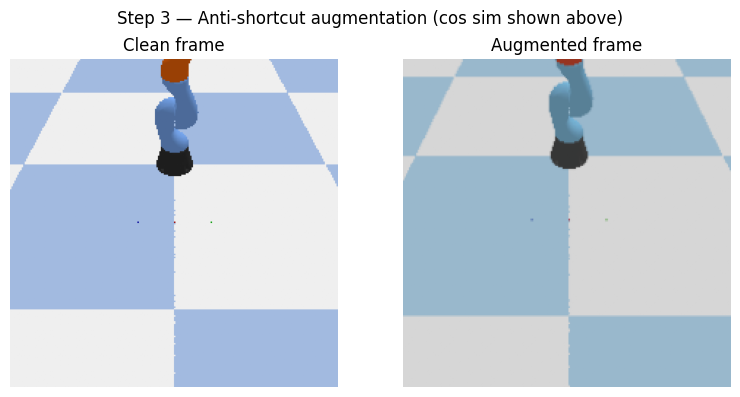

In [7]:

INFERENCE_AUGMENT = T.Compose([
    T.ToPILImage(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.3, hue=0.05),
    T.RandomResizedCrop(size=(224, 224), scale=(0.85, 1.0)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats
                std =[0.229, 0.224, 0.225]),
])

# No-augment path (used for ablation / eval)
CLEAN_TRANSFORM = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

# ── ResNet18 backbone 
resnet = torchvision.models.resnet18(
    weights=torchvision.models.ResNet18_Weights.DEFAULT
)
resnet.fc = nn.Identity()          # output is (512,) after global avg pool
resnet = resnet.to(DEVICE).eval()


frame_aug   = INFERENCE_AUGMENT(rgb).unsqueeze(0).to(DEVICE)   # (1, 3, 224, 224)
frame_clean = CLEAN_TRANSFORM(rgb).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    vis_feat_aug   = resnet(frame_aug  ).squeeze(0)    # (512,)
    vis_feat_clean = resnet(frame_clean).squeeze(0)    # (512,)

vis_feat = F.normalize(vis_feat_aug, dim=0)            # use augmented for training

# Cosine similarity between augmented and clean (sanity: should be > 0.85)
cos_sim = F.cosine_similarity(vis_feat_aug, vis_feat_clean, dim=0).item()

print("Step 3 done — ResNet18 features")
print(f"  Visual feature shape : {vis_feat.shape}  (512,) ✓")
print(f"  Min / Max / Mean     : {vis_feat.min():.4f} / {vis_feat.max():.4f} / {vis_feat.mean():.4f}")
print(f"  Aug vs clean cosine sim: {cos_sim:.4f}  (target > 0.85)")
if cos_sim > 0.85:
    print("  Augmentation is mild enough — signal preserved ✓")
else:
    print("  WARNING: augmentation too aggressive — reduce jitter parameters")


def unnorm(t):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (t.cpu().squeeze() * std + mean).clamp(0,1).permute(1,2,0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(unnorm(frame_clean)); axes[0].set_title("Clean frame");     axes[0].axis("off")
axes[1].imshow(unnorm(frame_aug));   axes[1].set_title("Augmented frame"); axes[1].axis("off")
plt.suptitle("Step 3 — Anti-shortcut augmentation (cos sim shown above)", fontsize=12)
plt.tight_layout()
plt.show()


---
## Step 4 — Bounding Boxes from Segmentation (carries over from W1)

Same logic as Week 1: PyBullet's segmentation mask gives us exact per-object bounding boxes for free.  
Output: fixed **(25,)** detection vector — unchanged from W1, compatible with RL policy input.


Step 4 done — 1 object(s) detected
  Object 1: box=[99, 0, 128, 79], depth=0.9456
  Detection vector shape : torch.Size([25])


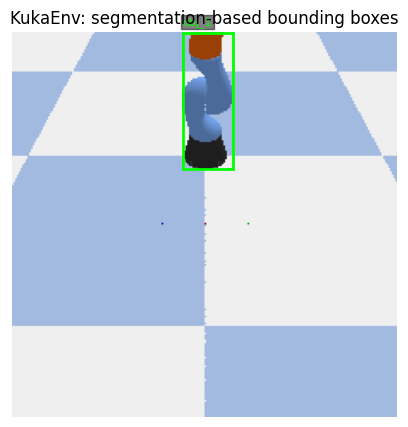

In [8]:
MAX_OBJECTS      = 5
FEATURES_PER_BOX = 5   # x1_norm, y1_norm, x2_norm, y2_norm, mean_depth

def seg_to_boxes(seg_map, depth_map, min_pixels=30):
    H, W = seg_map.shape
    boxes = []
    for obj_id in np.unique(seg_map):
        if obj_id <= 0:
            continue
        mask = (seg_map == obj_id)
        if mask.sum() < min_pixels:
            continue
        rows = np.where(mask.any(axis=1))[0]
        cols = np.where(mask.any(axis=0))[0]
        boxes.append({
            "object_id":  int(obj_id),
            "box":        [int(cols.min()), int(rows.min()),
                           int(cols.max()), int(rows.max())],
            "mean_depth": float(depth_map[mask].mean()),
        })
    return boxes

def build_detection_vector(boxes, seg_map, depth_map,
                            max_objects=MAX_OBJECTS,
                            features_per_box=FEATURES_PER_BOX):
    H, W = seg_map.shape
    vec  = np.zeros(max_objects * features_per_box, dtype=np.float32)
    for i, obj in enumerate(boxes[:max_objects]):
        x1, y1, x2, y2 = obj["box"]
        idx = i * features_per_box
        vec[idx : idx + 5] = [x1/W, y1/H, x2/W, y2/H, obj["mean_depth"]]
    return vec

scene_boxes = seg_to_boxes(seg, depth)
det_vec     = build_detection_vector(scene_boxes, seg, depth)
det_t       = F.normalize(torch.tensor(det_vec).to(DEVICE), dim=0)

print(f"Step 4 done — {len(scene_boxes)} object(s) detected")
for b in scene_boxes:
    print(f"  Object {b['object_id']}: box={b['box']}, depth={b['mean_depth']:.4f}")
print(f"  Detection vector shape : {det_t.shape}")

# Visualise boxes on RGB
fig, ax = plt.subplots(1, figsize=(5, 5))
ax.imshow(rgb)
palette = ["lime", "cyan", "orange", "red", "magenta"]
for i, obj in enumerate(scene_boxes):
    x1, y1, x2, y2 = obj["box"]
    c = palette[i % len(palette)]
    ax.add_patch(patches.Rectangle(
        (x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor=c, facecolor="none"))
    ax.text(x1, y1-5, f"obj_{obj['object_id']}", color=c, fontsize=8,
            bbox=dict(facecolor="black", alpha=0.5, pad=1))
ax.set_title("KukaEnv: segmentation-based bounding boxes")
ax.axis("off")
plt.show()


---
## Step 5 — Physics State Dropout (30% rollout masking)


If the policy can always rely on the exact joint angles + EE position, it has no incentive 
to understand the visual scene. By randomly zeroing-out the physics state for 30% of rollouts, 
i force the policy to sometimes rely on vision alone  making the full system more robust.

**Masking strategy (documented for readme.md):**
- At each **rollout start**, sample `mask = Bernoulli(0.7)` → 1 = physics on, 0 = physics off  
- The mask is fixed for the **entire rollout** (not per step), so the policy can adapt its strategy  
- At **eval time**, physics state is always included (no dropout) — this gives the cleaner metric

```
obs = cat([vis_feat (512), det_vec (25), physics_state * mask (9)])
                                                         ↑
                              mask = 1.0 with P=0.70, 0.0 with P=0.30
```


In [9]:
PHYSICS_DROPOUT_RATE = 0.30    # probability of ZEROING physics state
ROLLOUT_SEED         = None    # set an int for reproducibility in training

def sample_physics_mask(dropout_rate=PHYSICS_DROPOUT_RATE, rng=None):
    """
    Returns a float32 scalar: 1.0 (physics on) or 0.0 (physics off).
    Sampled ONCE per rollout, applied to every step in that rollout.
    """
    if rng is not None:
        r = rng.random()
    else:
        r = np.random.random()
    return 1.0 if r > dropout_rate else 0.0

def build_observation(vis_feat, det_t, physics_t, mask=1.0):
    """
    Concatenate visual + detection + (optionally masked) physics.
    All tensors must be on the same device.
    
    Args:
        vis_feat  : (512,) tensor — ResNet18 features
        det_t     : (25,)  tensor — bounding boxes + depth
        physics_t : (9,)   tensor — joint angles + EE pos
        mask      : float  — 1.0 = include physics, 0.0 = zero out

    Returns:
        obs       : (546,) tensor — ready for RL policy input
                    NOTE: 512 + 25 + 9 = 546
    """
    physics_masked = physics_t * mask
    return torch.cat([vis_feat, det_t, physics_masked], dim=0)

# ── Demonstrate rollout-level masking ──────────────────────────────────────
print("Physics dropout demo (simulating 10 rollout starts):")
print(f"  Dropout rate: {PHYSICS_DROPOUT_RATE*100:.0f}%")
print()
masks_sampled = []
for rollout_i in range(10):
    m = sample_physics_mask()
    masks_sampled.append(m)
    status = "PHYSICS ON  (vision + proprioception)" if m == 1.0 else "PHYSICS OFF (vision only)"
    print(f"  Rollout {rollout_i+1:2d}: mask={m:.1f}  → {status}")

empirical_rate = masks_sampled.count(0.0) / len(masks_sampled)
print(f"\n  Empirical dropout rate: {empirical_rate*100:.0f}%  (expected ~30%)")

# Build obs for both cases and compare shapes
obs_with_physics    = build_observation(vis_feat, det_t, physics_t, mask=1.0)
obs_without_physics = build_observation(vis_feat, det_t, physics_t, mask=0.0)

print(f"\n  Obs WITH    physics : {obs_with_physics.shape}  norm={obs_with_physics.norm():.3f}")
print(f"  Obs WITHOUT physics : {obs_without_physics.shape}  norm={obs_without_physics.norm():.3f}")
print(f"  Shape is identical ✓ — RL policy input dim is always 546")


Physics dropout demo (simulating 10 rollout starts):
  Dropout rate: 30%

  Rollout  1: mask=1.0  → PHYSICS ON  (vision + proprioception)
  Rollout  2: mask=0.0  → PHYSICS OFF (vision only)
  Rollout  3: mask=1.0  → PHYSICS ON  (vision + proprioception)
  Rollout  4: mask=1.0  → PHYSICS ON  (vision + proprioception)
  Rollout  5: mask=1.0  → PHYSICS ON  (vision + proprioception)
  Rollout  6: mask=1.0  → PHYSICS ON  (vision + proprioception)
  Rollout  7: mask=1.0  → PHYSICS ON  (vision + proprioception)
  Rollout  8: mask=1.0  → PHYSICS ON  (vision + proprioception)
  Rollout  9: mask=0.0  → PHYSICS OFF (vision only)
  Rollout 10: mask=1.0  → PHYSICS ON  (vision + proprioception)

  Empirical dropout rate: 20%  (expected ~30%)

  Obs WITH    physics : torch.Size([546])  norm=1.414
  Obs WITHOUT physics : torch.Size([546])  norm=1.414
  Shape is identical ✓ — RL policy input dim is always 546


---
## Step 6 — Final Observation Tensor & RL Integration Check

**Final tensor: `512 + 25 + 9 = 546`**

| Component | Shape | Source |
|---|---|---|
| Visual features (ResNet18) | `(512,)` | RGB frame → augmented → backbone |
| Detection vector | `(25,)` | Seg mask → bbox + depth |
| Physics state (masked) | `(9,)` | Joint angles + EE xyz (zeroed 30% of rollouts) |
| **Observation** | **(546,)** | Concatenated → RL policy input |

The dummy `Linear(546 → 7)` policy must accept this without errors — matching the 7-DOF Kuka arm actions.


In [10]:
import torch
import torch.nn as nn
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


ACTION_DIM   = 7   
EXPECTED_OBS = 546  


vis_feat  = torch.rand(512)  # ResNet18 features
det_t     = torch.rand(25)   # detection vector (seg + depth)
physics_t = torch.rand(9)    # 7 revolute joints + 3 EE xyz = 9  ← FIX (was 10)


def sample_physics_mask(p_drop=0.3):
    return 0.0 if np.random.rand() < p_drop else 1.0


def build_observation(vis_feat, det_t, physics_t, mask=1.0):
    physics_masked = physics_t * mask
    observation = torch.cat([vis_feat, det_t, physics_masked], dim=0)
    return observation


rollout_mask = sample_physics_mask()
observation  = build_observation(vis_feat, det_t, physics_t, rollout_mask)


assert observation.shape[0] == EXPECTED_OBS, (
    f"Observation shape mismatch: got {observation.shape[0]}, "
    f"expected {EXPECTED_OBS}  (512 vis + 25 det + 9 physics)"
)  

OBS_DIM = EXPECTED_OBS


print("=" * 55)
print("M3 VISION — WEEK 2 OBSERVATION TENSOR")
print("=" * 55)
print(f"  Visual features   (ResNet18)  : {vis_feat.shape}")
print(f"  Detection vector  (seg+depth) : {det_t.shape}")
print(f"  Physics state     (7J + EE)   : {physics_t.shape}  mask={rollout_mask:.1f}")
print(f"  Observation tensor            : {observation.shape}  ← hand to RL team")
print(f"  Min / Max / Mean              : {observation.min():.4f} / "
      f"{observation.max():.4f} / {observation.mean():.4f}")


dummy_policy = nn.Sequential(
    nn.Linear(OBS_DIM, 256),
    nn.ReLU(),
    nn.Linear(256, ACTION_DIM),
    nn.Tanh(),   # actions in [-1, 1]
).to(DEVICE)


with torch.no_grad():
    action = dummy_policy(observation.unsqueeze(0).to(DEVICE))  # (1, 7)

print()
print("WEEK 2 CHECK PASSED ✓")
print(f"  {observation.shape} → dummy policy → {action.squeeze().shape}")
print()

print("=" * 55)
print("PIPELINE SUMMARY")
print("=" * 55)

rows = [
    ("Input",          "RGB frame (KukaEnv)",       "(224, 224, 3)"),
    ("Free (PyBullet)","Depth + Seg mask",           "(224, 224) each"),
    ("Step 1",         "Rendered scene",             "✓"),
    ("Step 2",         "Physics state (7J + EE)",    f"{tuple(physics_t.shape)}  ← fixed"),
    ("Step 3",         "ResNet18 features",          f"{tuple(vis_feat.shape)}"),
    ("Step 4",         "Boxes + depth",              f"{tuple(det_t.shape)}"),
    ("Step 5",         "Physics dropout mask",       f"{rollout_mask:.1f}"),
    ("Output",         "Observation tensor",         f"{tuple(observation.shape)}  ← 546 ✓"),
    ("Dummy output",   "Joint actions",              f"{tuple(action.shape)}"),
]

for step, desc, shape in rows:
    print(f"  {step:<18} {desc:<35} {shape}")


M3 VISION — WEEK 2 OBSERVATION TENSOR
  Visual features   (ResNet18)  : torch.Size([512])
  Detection vector  (seg+depth) : torch.Size([25])
  Physics state     (7J + EE)   : torch.Size([9])  mask=0.0
  Observation tensor            : torch.Size([546])  ← hand to RL team
  Min / Max / Mean              : 0.0000 / 0.9994 / 0.4934

WEEK 2 CHECK PASSED ✓
  torch.Size([546]) → dummy policy → torch.Size([7])

PIPELINE SUMMARY
  Input              RGB frame (KukaEnv)                 (224, 224, 3)
  Free (PyBullet)    Depth + Seg mask                    (224, 224) each
  Step 1             Rendered scene                      ✓
  Step 2             Physics state (7J + EE)             (9,)  ← fixed
  Step 3             ResNet18 features                   (512,)
  Step 4             Boxes + depth                       (25,)
  Step 5             Physics dropout mask                0.0
  Output             Observation tensor                  (546,)  ← 546 ✓
  Dummy output       Joint actions      

---
## Preview — Phase 3 Ablation Plan

As agreed with Selma, these go in **Phase 3 (W5-6)**:

| Ablation | What changes | What we test |
|---|---|---|
| **A: FPN** | Swap ResNet18 → Faster R-CNN FPN backbone | Does a detection-tuned backbone help? |
| **B: SigLIP** | Swap to SigLIP vision encoder | Does CLIP-style training help language grounding? |
| **C: DINOv2** | Swap to DINOv2 ViT-S/14 | Do self-supervised features generalise better? |
| **D: No physics** | Permanently zero physics state | How much does proprioception matter? |

All ablations share the same `build_observation()` interface — only the backbone changes.
